# **Exercício Computacional: Regressão Linear e Regularização**

## Orientações
- Use apenas `numpy` e `matplotlib`
- Complete as partes indicadas
- Interprete os gráficos obtidos
- Responda às perguntas conceituais ao final

In [10]:
# Importando bibliotecas

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



---

## Parte 1 — Geração de Dados

Considere o modelo:

$$
y = -\sin(x/5) + \cos(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, (0.2)^2)
$$


Para este modelo, pede-se

1. Gere um conjunto de treino com \(N=10\)
2. Gere um conjunto de teste com \(N=20\)
3. Considere $x \in [-5,5]$
4. Plote os dados de treino

In [11]:
# Defina aqui a função ``real'' do modelo (conforme enunciado)

def f_true(x):
    x = np.array(x) # garante que x seja um array numpy
    y = -np.sin(x / 5) + np.cos(x) # calcula os valores de y usando a função do enunciado
    return y

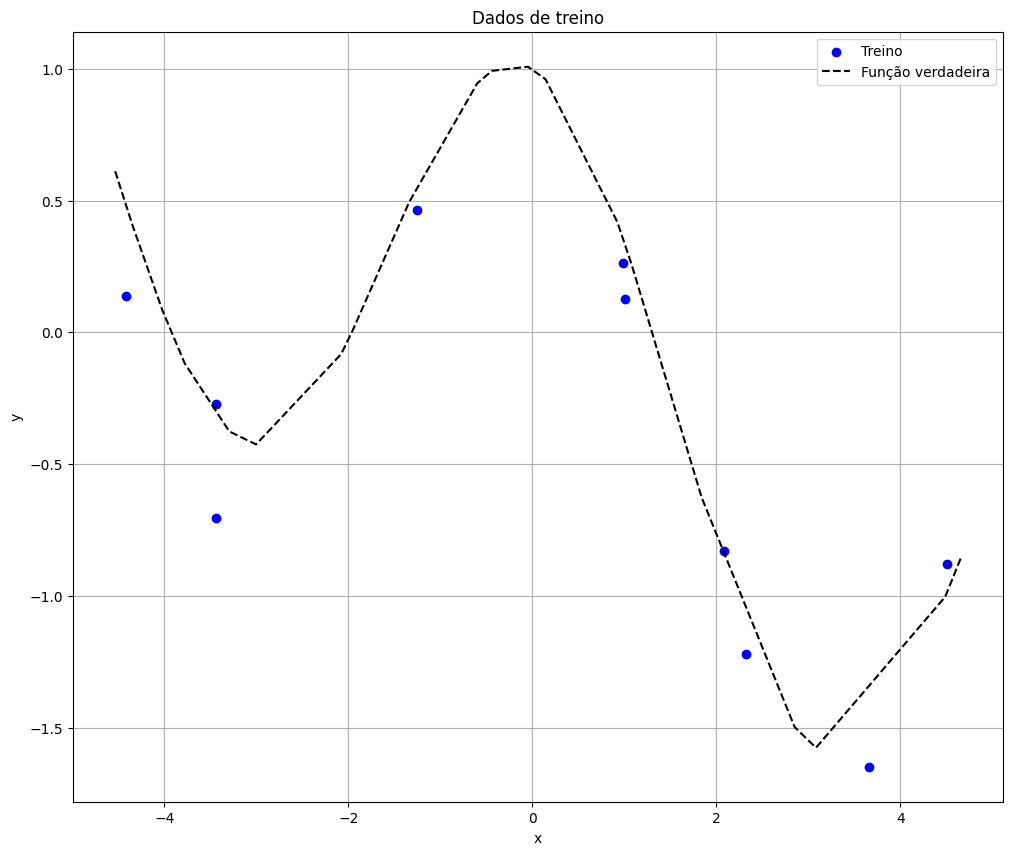

In [12]:
# Defina adequadamente a quantidade e os dados de treino e teste, utilizando a função f_true(x)

# Dados de treino
N_train = 10
x_train = np.random.uniform(-5, 5, N_train) # gera os valores de x de treino
y_train = f_true(x_train) + np.random.normal(0, 0.2, N_train) # gera os valores de y de treino com ruído conforme enunciado

# Dados de teste
N_test = 20
x_test = np.sort(np.random.uniform(-5, 5, N_test)) # gera os valores de x de teste / tive que colocar esse sort para a curva ficar adequada
y_test = f_true(x_test) + np.random.normal(0, 0.2, N_test) # gera os valores de y de teste com ruído conforme enunciado

# Visualização
plt.figure(figsize=(12, 10))
plt.scatter(x_train, y_train, color='blue', label='Treino')
plt.plot(x_test, f_true(x_test), color='black', linestyle='--', label='Função verdadeira')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dados de treino')
plt.legend()
plt.grid(True)
plt.show()

## Parte 2 — Regressão Polinomial por MLE e Ridge

Considere as features:

$$\boldsymbol{\phi}(x) = [1, x, x^2, \dots, x^M]$$

e os estimadores:

$$\theta_{ML} = (\Phi^\top \Phi)^{-1}\Phi^\top y$$

$$
\theta_{Ridge} = (\Phi^\top \Phi + \lambda I)^{-1}\Phi^\top y
$$

Para auxiliar na implementação da regressão, implemente as seguintes funções auxiliares:
1. a matriz de features polinomiais
2. o estimador MLE
3. o estimador Ridge (LS com regularização quadrática)
4. a métrica RMSE

In [13]:
# função que cria a matriz que contém, em cada linha, as potências de x, i.e., [1 x x^2 x^3 ... x^M]
def phi(x, M):
    Phi = np.column_stack([x**i for i in range(M + 1)]) 
    return Phi

# função que obtém o estimador MLE
def mle(Phi, y):
    return np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y 

# função que obtém o estimador de mínimos quadrados com regularização quadrática (parâmetro lam de regularização)
def ridge(Phi, y, lam):
    ridge = np.linalg.inv(Phi.T @ Phi + lam * np.eye(Phi.shape[1])) @ Phi.T @ y 
    return ridge 

# função que estima o rmse entre os valores preditos e os verdadeiros
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2)) 



## Parte 3 — Teste da Regressão Polinomial por MLE

Utilizando as funções já implementadas:
1. Ajuste modelos para $M = 0,1,\dots,9$
2. Calcule RMSE de treino e teste
3. Plote:
   - as curvas ajustadas
   - RMSE em função do grau

In [14]:
# Insira seu código referente aos itens 1. e 2.
graus = range(10) # graus dos polinômioS
rmse_train_mle = [] # armazenar os RMSEs do MLE
rmse_test_mle = [] # armazenar os RMSEs do MLE
thetas_mle = [] # armazenar os parâmetros do MLE

for M in graus:
    Phi_train = phi(x_train, M) # matriz de características de treino
    Phi_test = phi(x_test, M) # matriz de características de teste
    
    theta_mle = mle(Phi_train, y_train) # obtém o estimador MLE
    thetas_mle.append(theta_mle) # armazena os parâmetros MLE
    
    y_pred_train_mle = Phi_train @ theta_mle # predições de treino usando o MLE
    y_pred_test_mle = Phi_test @ theta_mle # predições de teste usando o MLE
    
    rmse_train_mle.append(rmse(y_train, y_pred_train_mle)) # calcula e armazena o RMSE de treino do MLE
    rmse_test_mle.append(rmse(y_test, y_pred_test_mle)) # calcula e armazena o RMSE de teste do MLE 

# Loop para imprimir os resultados
print("Comparação de desempenho para cada grau de polinômios (M = 9)")
print("-" * 60)

for M in graus:
    print(f"Grau {M}: RMSE Treino = {rmse_train_mle[M]:.4f}, RMSE Teste = {rmse_test_mle[M]:.4f}")

Comparação de desempenho para cada grau de polinômios (M = 9)
------------------------------------------------------------
Grau 0: RMSE Treino = 0.6695, RMSE Teste = 0.8749
Grau 1: RMSE Treino = 0.5577, RMSE Teste = 0.7576
Grau 2: RMSE Treino = 0.4813, RMSE Teste = 0.6500
Grau 3: RMSE Treino = 0.4692, RMSE Teste = 0.6381
Grau 4: RMSE Treino = 0.1172, RMSE Teste = 0.2271
Grau 5: RMSE Treino = 0.1168, RMSE Teste = 0.2296
Grau 6: RMSE Treino = 0.1056, RMSE Teste = 0.2094
Grau 7: RMSE Treino = 0.1006, RMSE Teste = 0.8744
Grau 8: RMSE Treino = 0.1003, RMSE Teste = 5.5533
Grau 9: RMSE Treino = 0.0000, RMSE Teste = 403.2007


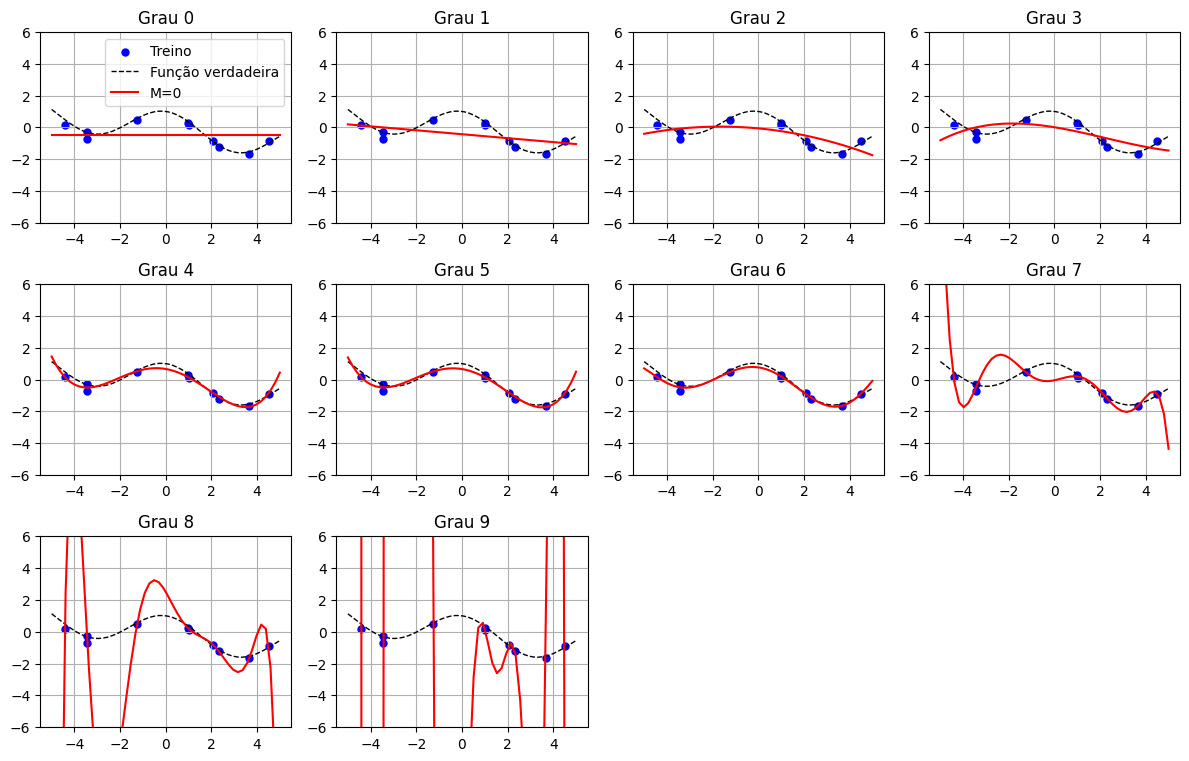

In [15]:
# Insira seu código para plotar as curvas ajustadas
x_grid = np.linspace(-5, 5) # gera um grid de valores de x 

plt.figure(figsize=(12, 10)) 

# Loop para plotar as curvas ajustadas para cada grau M
for i, M in enumerate(graus):
    plt.subplot(4, 4, i + 1)

    y_grid = phi(x_grid, M) @ thetas_mle[i] # calcula as predições para o grid usando os parâmetros MLE

    plt.scatter(x_train, y_train, color='blue', s=25, label='Treino')
    plt.plot(x_grid, f_true(x_grid), 'k--', linewidth=1.0, label='Função verdadeira')
    plt.plot(x_grid, y_grid, color='red', linewidth=1.5, label=f'M={M}')

    plt.title(f'Grau {M}')
    plt.ylim(-6, 6)
    plt.grid(True)

    if i == 0:
        plt.legend(loc = 'upper right')

plt.tight_layout()
plt.show()

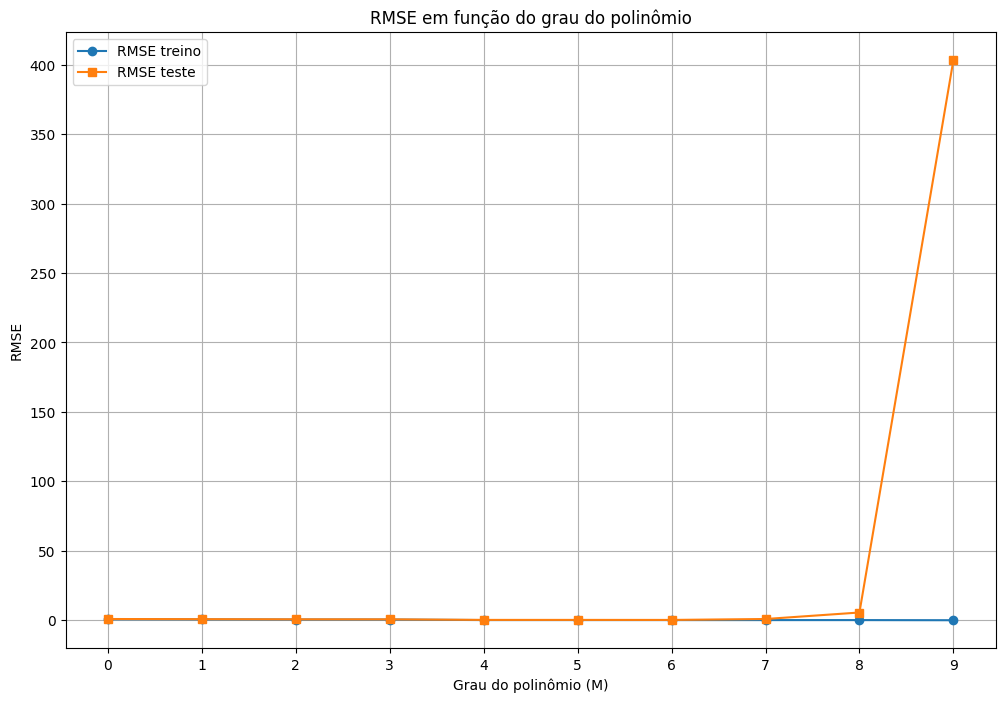

In [16]:
# Insira seu código para plotar a curva de RMS em função do grau (tanto treino, como teste)
plt.figure(figsize=(12, 8)) 
plt.plot(list(graus), rmse_train_mle, marker='o', label='RMSE treino')
plt.plot(list(graus), rmse_test_mle, marker='s', label='RMSE teste')
plt.xlabel('Grau do polinômio (M)')
plt.ylabel('RMSE')
plt.title('RMSE em função do grau do polinômio')
plt.xticks(list(graus))
plt.grid(True)
plt.legend()
plt.show()

## Parte 4 — Overfitting

Responda:

1. Por que o erro de treino tende a diminuir quando o grau do polinômio aumenta?
2. Por que o erro de teste pode aumentar para graus altos?
3. Em qual faixa de graus há sinais de overfitting?
4. Qual grau parece oferecer melhor generalização?

Justifique suas respostas

Respostas:

1.  O erro de treino tende a diminuir porque, ao aumentar o grau do polinômio, o modelo ganha mais flexibilidade e passa a ter maior capacidade de se ajustar aos pontos observados no conjunto de treino, inclusive ao ruído, o que acaca comprometendo o desempenho do modelo em modelos muito flexiveis (i.e., elevado grau do polinômio). 

2. O erro de teste pode aumentar para graus altos porque o modelo passa a se ajustar excessivamente aos dados de treinamento. Esse ajuste exagerado reduz a capacidade de previsão do modelo, fazendo com que o desempenho em dados não observados (conjunto de teste) piore, ou seja, piora a generalização.

3. Há sinais de overfitting nos graus mais altos, especialmente a partir de M = 8-9, quando o RMSE de treino permanece baixo, mas o RMSE de teste cresce, em particular no M=9, onde o RMSE aumenta de forma acentuada.

4. A melhor generalização acontece no grau 6 (M = 6), onde o RMSE do conjunto de teste é 0.2094. 








## Parte 5 — Regularização Ridge

Para o estimador com Ridge regression, pede-se
### Tarefas
1. Fixe $M=9$
2. Teste:
   $\lambda = 0,\ 10^{-3},\ 10^{-1},\ 1,\ 10$
3. Compare as curvas ajustadas
4. Compare RMSE de treino e teste

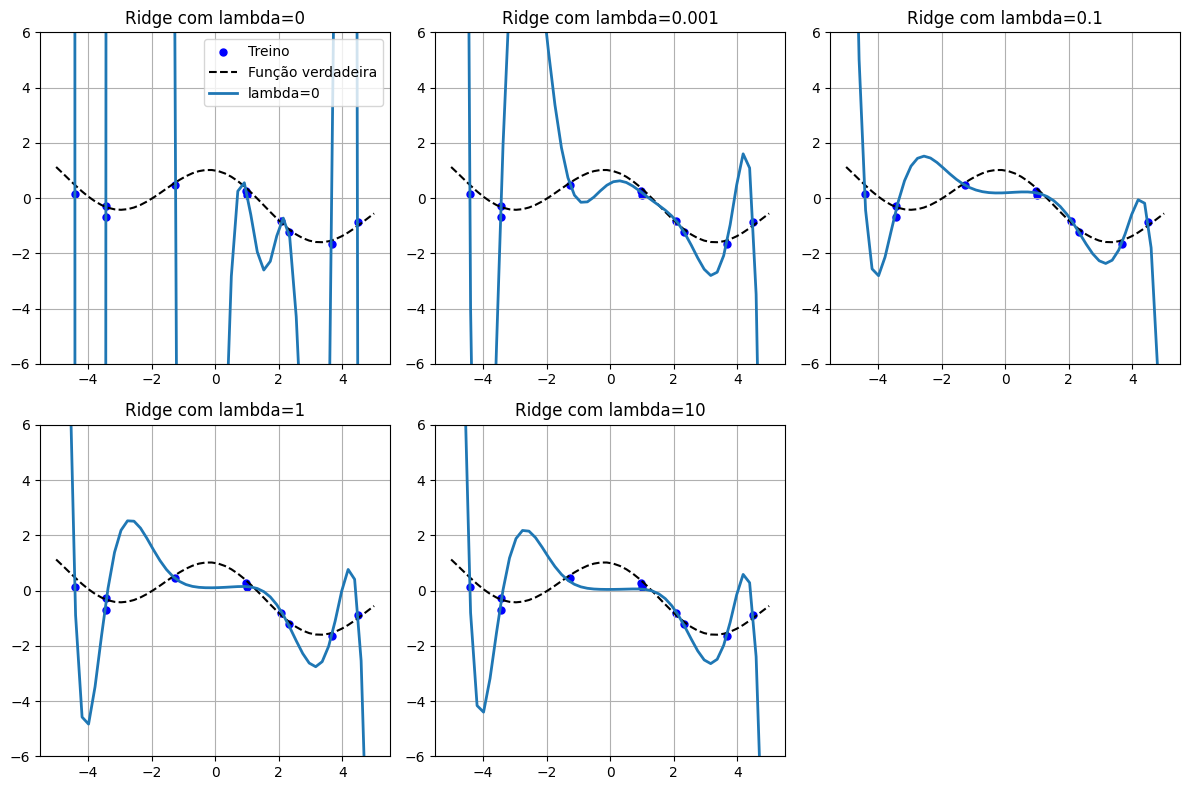

In [17]:
# Insira seu código aqui para comparação das curvas ajustadas
M = 9 # grau do polinômio
lambdas = [0, 1e-3, 1e-1, 1, 10]

x_grid = np.linspace(-5, 5) # gera um grid de valores de x

thetas_ridge = {}
rmse_ridge_train = []
rmse_ridge_test = []

plt.figure(figsize=(12, 8))

for i, lam in enumerate(lambdas):
    Phi_train = phi(x_train, M)
    Phi_test = phi(x_test, M)
    theta = ridge(Phi_train, y_train, lam)
    thetas_ridge[lam] = theta

    y_grid = phi(x_grid, M) @ theta
    yhat_train = Phi_train @ theta
    yhat_test = Phi_test @ theta

    rmse_ridge_train.append(rmse(y_train, yhat_train))
    rmse_ridge_test.append(rmse(y_test, yhat_test))

    
    plt.subplot(2, 3, i + 1)
    plt.scatter(x_train, y_train, color='blue', s=25, label='Treino')
    plt.plot(x_grid, f_true(x_grid), 'k--', linewidth=1.5, label='Função verdadeira')
    plt.plot(x_grid, y_grid, linewidth=2, label=f'lambda={lam}')
    plt.title(f'Ridge com lambda={lam}')
    plt.ylim(-6, 6)
    plt.grid(True)

    if i == 0:
        plt.legend(loc = 'upper right')

plt.tight_layout()
plt.show()


Comparação de desempenho para M = 9
----------------------------------------
lambda =     0: RMSE treino = 0.0000 | RMSE teste = 403.2007
lambda = 0.001: RMSE treino = 0.0978 | RMSE teste = 8.0901
lambda =   0.1: RMSE treino = 0.1008 | RMSE teste = 1.2475
lambda =     1: RMSE treino = 0.1067 | RMSE teste = 2.1461
lambda =    10: RMSE treino = 0.1296 | RMSE teste = 1.9467


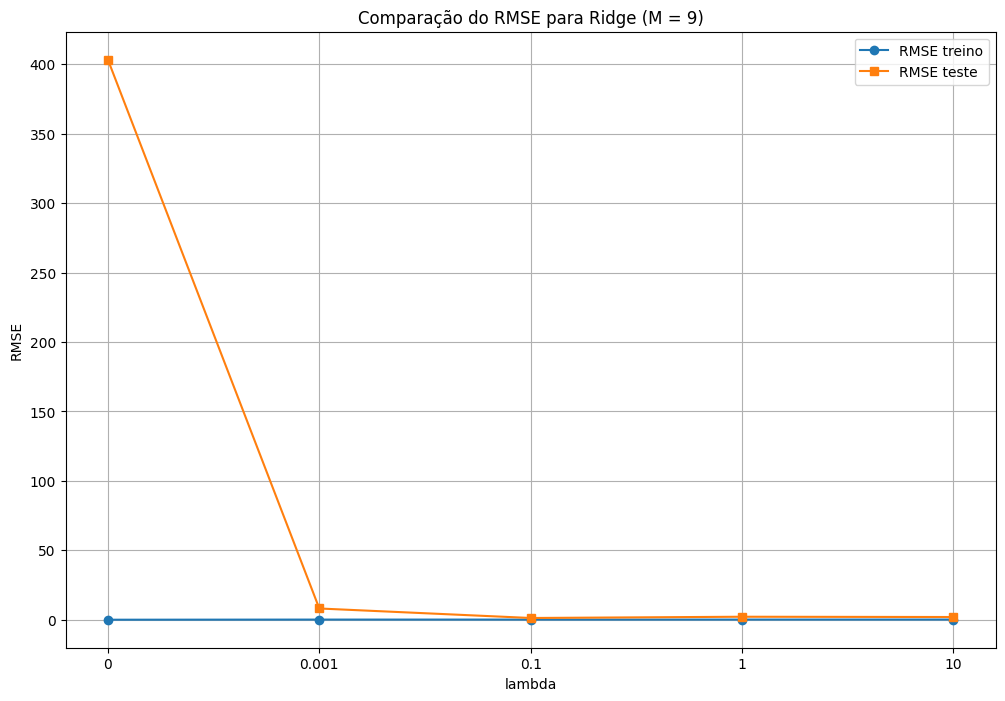

In [18]:
# Insira seu códivo aqui para a comparação do RMSE de treino e teste
print("Comparação de desempenho para M = 9")
print("-" * 40)
for lam, rtr, rte in zip(lambdas, rmse_ridge_train, rmse_ridge_test):
    print(f"lambda = {lam:>5}: RMSE treino = {rtr:.4f} | RMSE teste = {rte:.4f}")

plt.figure(figsize=(12, 8))
plt.plot(np.arange(len(lambdas)), rmse_ridge_train, marker='o', label='RMSE treino')
plt.plot(np.arange(len(lambdas)), rmse_ridge_test, marker='s', label='RMSE teste')
plt.xticks(np.arange(len(lambdas)), [str(l) for l in lambdas])
plt.xlabel('lambda')
plt.ylabel('RMSE')
plt.title('Comparação do RMSE para Ridge (M = 9)')
plt.grid(True)
plt.legend()
plt.show()

## Parte 6 — Relação entre Ridge e MAP

Sabemos que, para prior Gaussiano $p(\theta) = \mathcal{N}(0, b^2 I)$

a estimativa MAP leva à solução

$
\theta_{MAP} = (\Phi^\top \Phi + \lambda I)^{-1}\Phi^\top y
$

com

$
\lambda = \frac{\sigma^2}{b^2}
$

Responda:

1. Qual o efeito de escolher um valor grande de $\lambda$?
2. Qual o efeito de escolher uma variância $\mathcal b^2$ pequena no prior?
3. Por que a regularização ajuda a reduzir overfitting?
4. Em que sentido Ridge pode ser interpretado como MAP?

Respostas:

1. Ao escolher um valor de $\lambda$ grande há uma penalização nos coeficientes do modelo, forçando-o a assumir magnitudes menores. Consequentemente, as curvas do modelo se tornam mais suaves e menos flexíveis.  

2. Como $\lambda = \frac{\sigma^2}{b^2}$, escolher um prior com variância $\mathcal b^2$ pequena implica em um \$\lambda$ maior. Isso significa que um prior com variância pequena produz uma penalização Ridge mais forte. 

3. A regularização ajuda a reduzir overfitting porque evita coeficientes muito grandes e, deste modo, reduz a complexidade do modelo. Assim, o ajuste fica menos sensível ao ruído dos dados de treino e tende a generalizar melhor.

4. Ridge pode ser vista como uma estimativa MAP porque é equivalente a maximizar a distribuição a posteriori quando assumimos um prior Gaussiano centrado em zero para os coeficientes. Assim, a penalização da Ridge reflete a crença prévia de que coeficientes muito grandes são menos prováveis e, por isso, são contraídos em direção a zero.


# Parte 7 - Conclusões

Responda de forma objetiva:

1. Qual a principal limitação da estimativa por máxima verossimilhança?
2. Por que polinômios de grau alto podem ajustar bem o treino e mal o teste?
3. Qual a diferença prática entre MLE e Ridge?
4. Como o parâmetro $\lambda$ afeta a complexidade do modelo?
5. O que acontece com o modelo quando $\lambda \to \infty$?

Respostas:

1. A principal limitação da estimativa por máxima verossimilhança é que ela não penaliza a complexidade do modelo, o que pode levar a overfitting e a estimativas instáveis, especialmente em modelos muito flexíveis.

2. Polinômios de alto grau tendem a se ajustar excessivamente aos dados de treinamento, inclusive captando os ruídos dos dados e, por isso podem generalizar mal para dados não observados.

3. MLE busca apenas minimizar o erro de ajuste aos dados, enquanto Ridge adiciona uma penalização sobre os coeficientes, controlando a complexidade e potencialmente melhorando a generalização.

4. O parâmetro $\lambda$ controla a força da regularização: valores maiores reduzem a magnitude dos coeficientes em direção a zero e, portanto, tornam o modelo mais simples; valores menores deixam o modelo mais livre e flexível.

5. Quanto $\lambda \to \infty$ os coeficientes tendem a zero e o modelo se torna extremamente simples, perdendo capacidade de ajuste aos dados.